In [1]:
import kagglehub

path = kagglehub.dataset_download("gergvincze/simple-hand-drawn-and-digitized-images")

/Users/igawolanin/Desktop/Practice/Solvro-recruitment-task/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#imports
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
torch.manual_seed(SEED)

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Loading images and creating labels
Labels were mapped to an integer and stored in a dictionary. To make life easier, a reverse dictionary was also implemented.

In [4]:
class_to_num = {}
data = []
labels = []
i = 0
for directory in os.listdir(path):
        path_to_files = path +"/" + directory
        for file in os.listdir(path_to_files):
            img = Image.open(path_to_files + "/" + file)
            img = np.asarray(img)
            data.append(img)
            if directory not in class_to_num:
                class_to_num[directory] = i
                i+=1
            labels.append(class_to_num[directory])

if len(data) != len(labels):
    print("Error with loading data")

labels = np.array(labels)
data = np.array(data)

Dictionary comprehension.

In [5]:
num_to_class = {y:x for x,y in class_to_num.items()}

# Dataset Evaluation

### Sample visualisation
Images vary in quality. Some are digitally written, some are handwritten on a plain background and some are handwritten on a square paper. If images are handwritten, the background appears more gray than white.

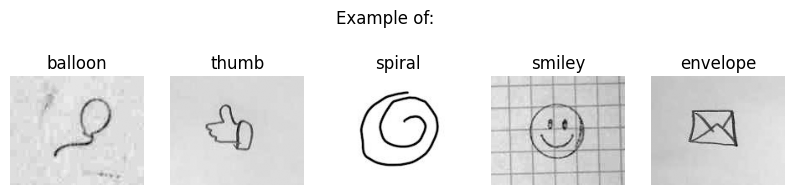

In [6]:
plt.figure(figsize=(10,2.5))
for i in range(5):
    plt.subplot(1,5,i + 1)
    plt.imshow(data[i*60], cmap='gray')
    plt.axis('off')
    plt.title(num_to_class[labels[i*60]])
plt.suptitle('Example of:')
plt.show()

There are 10 unique classes.

In [7]:
classes = np.unique(labels)
print(f"{len(classes)} classes: ")
for k in class_to_num:
    print(k)

10 classes: 
balloon
thumb
spiral
peace_symbol
smiley
envelope
paper_boat
anchor
bicycle
speech_bubble


Data is balanced, although dataset is VERY small - the number of samples for each class is between 41 and 44. Data augmentation is necessary in this case. Data is not normalised, which is another step to do.

label
0    43
1    44
2    43
3    43
4    43
5    44
6    42
7    44
8    44
9    41
dtype: int64


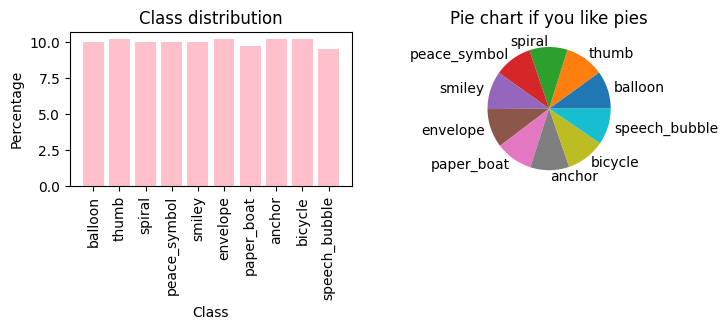

In [8]:
def get_percentage(series):
    summ = series.sum()
    percentages = []
    for val in series:
        percentages.append(np.round(val/summ*100,2))
    return percentages

labels_pd = pd.DataFrame(labels, columns=['label'])
count = labels_pd.groupby('label').size()
print(count)
arr = get_percentage(count)

class_names= [num_to_class[i] for i in range(10)]
plt.figure(figsize=(8,2))
plt.subplot(1,2,1)
plt.bar(class_names, arr, color='pink')
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.title("Class distribution")
plt.xticks(rotation=90)
plt.subplot(1,2,2)
plt.pie(arr,labels=class_names)
plt.title("Pie chart if you like pies")
plt.show()

# Preprocessing

Pipeline:
split to train, test, val --> load to Dataset object --> transformation applied on __getitem__() --> DataLoader batching --> training

Mean and standard deviation need to be calculated on the entire train set, before distinction of the validation set.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.15, stratify=labels, random_state=SEED)
mean = X_train.mean() / 255.0
std = X_train.std() / 255.0
X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, test_size=len(X_test), stratify=y_train, random_state=SEED)

I decided to augment the data with geometric transformations. Color and appearance adjustments aren't appropriate, since the images are in greyscale and are very simple. More aggresive technics, such as cutouts seem also unnecessary.
Only train data will be augmented. The original images are never horizontally flipped, so appplying horizontal flips would introduce orientations that do not appear in test data. Horizontal flipping can only be applied to symmetric data, such as smiley faces and envelopes, where transformation doesn't change the semantic meaning.

In [10]:
# transform for symmetric pictures, that can be flipped
transform_flip = transforms.Compose([
    transforms.ConvertImageDtype(torch.float32),
    transforms.RandomAffine(degrees=15, translate=(0.05,0.05), scale=(0.9,1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Normalize(
    mean=[mean, mean, mean],
    std=[std, std, std]
)
])

# transform for nonsymmetric data that cannot be flipped
transform_noflip = transforms.Compose([
    transforms.ConvertImageDtype(torch.float32),
    transforms.RandomAffine(degrees=15, translate=(0.05,0.05), scale=(0.9,1.1)),
    transforms.Normalize(
    mean=[mean, mean, mean],
    std=[std, std, std]
)
])

#transform for test data, no geometric transforms, only converting to float, normalizing and standardizing
transform_test = transforms.Compose([
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(
    mean=[mean, mean, mean],
    std=[std, std, std]
)
])

### List of classes that can be flipped

In [11]:
flippable_classes = [3,4,5,6,7]
for x in class_to_num:
    print(x, ": ", class_to_num[x])

balloon :  0
thumb :  1
spiral :  2
peace_symbol :  3
smiley :  4
envelope :  5
paper_boat :  6
anchor :  7
bicycle :  8
speech_bubble :  9


# Dataset
Dataset converts input data to torch tensor. Before returning item in __getitem__ it transforms data using previously initialized transforms.

In [12]:
class ImgDataset(Dataset):
    def __init__(self, data, labels, is_train):
        if len(data) != len(labels):
            raise ValueError("Dataset must have the same length as labels")
        self.data = data
        self.labels  = labels
        self.is_train = is_train
        if not isinstance(self.data, torch.Tensor):
            self.data = torch.from_numpy(self.data)
        if not isinstance(self.labels, torch.Tensor):
            self.labels = torch.from_numpy(self.labels)
        self.data = self.data.unsqueeze(1) # added a dimension of the channel (greyscale = 1)

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        sample = sample.repeat(3, 1, 1)
        if self.is_train:
            if int(label) in flippable_classes:
                sample = transform_flip(sample)
            else:
                sample = transform_noflip(sample)
        else:
            sample = transform_test(sample)
        return sample, label

In [13]:
test_set = ImgDataset(X_test, y_test, False)
train_set = ImgDataset(X_train2, y_train2, True)
val_set = ImgDataset(X_val, y_val, False)

print(f"Train/Test/Val:{len(train_set)}/{len(test_set)}/{len(val_set)}")

Train/Test/Val:301/65/65


In [14]:
BATCH_SIZE = 16
train_loader  = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

### Helper function to visualize training progress

In [15]:
def show_training_process(history):
    x = []
    for i in range(len(history['tl'])):
        x.append(i+1)
    x = np.array(x)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(x, history['tl'], label='Train loss', color='pink')
    plt.plot(x, history['vl'], label='Validation loss', color='orchid')
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(x, history['ta'], label='Train accuracy', color='pink')
    plt.plot(x, history['va'], label='Validation accuracy', color='orchid')
    plt.title("Accuracy")
    plt.legend()
    plt.show()

# Model
### Question is: Which approach performs better as a feature extraction method for classification on this dataset?
I would suspect, tuning only the last layer will give better performance.
### Helper function to run an epoch
Function running one train/test/val epoch returning average loss and average accuracy

In [16]:
def run_epoch(loader, model, criterion, is_train, optimizer=None):
    epoch_loss, correct, total = 0,0,0
    if is_train:
        model.train()
    else:
        model.eval()
    with torch.set_grad_enabled(is_train):
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            if (is_train):
                optimizer.zero_grad()
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            if (is_train):
                loss.backward()
                optimizer.step()
            epoch_loss += loss.item() * x_batch.size(0)
            preds = predictions.argmax(1)
            correct += (preds==y_batch).sum().item()
            total += y_batch.size(0)
    return epoch_loss / total, correct / total

Function running run_epoch() multiple times, storing returned accuracy and loss in a history array.

In [17]:
def run_epochs(epochs, train_loader, val_loader, model, optimizer, criterion):
    history = {
        "tl": [], "ta": [],
        "vl":   [], "va":   []
    }
    for epoch in range(epochs):
        train_loss, train_accuracy = run_epoch(train_loader, model, criterion, True, optimizer)
        val_loss, val_accuracy = run_epoch(val_loader, model, criterion, False)

        history["tl"].append(train_loss)
        history["ta"].append(train_accuracy)

        history["vl"].append(val_loss)
        history["va"].append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {train_loss:.4f}, acc: {train_accuracy:.4f} | val loss: {val_loss:.4f}, acc: {val_accuracy:.4f}")

    return history

## Retraining the entire model
Results are very good, with validation accuracy reaching 1.0. I don't suspect overfitting, because train and validation accuracy are both very high.

In [18]:
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features

model.fc = nn.Linear(num_ftrs, 10)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

history = run_epochs(10, train_loader, val_loader, model, optimizer_ft, criterion)

Epoch 1/10 | train loss: 2.1716, acc: 0.2292 | val loss: 1.6035, acc: 0.5077
Epoch 2/10 | train loss: 1.1263, acc: 0.7209 | val loss: 0.4653, acc: 0.9231
Epoch 3/10 | train loss: 0.4867, acc: 0.9169 | val loss: 0.1612, acc: 0.9692
Epoch 4/10 | train loss: 0.1926, acc: 0.9701 | val loss: 0.0905, acc: 0.9846
Epoch 5/10 | train loss: 0.1218, acc: 0.9900 | val loss: 0.0462, acc: 1.0000
Epoch 6/10 | train loss: 0.0770, acc: 0.9934 | val loss: 0.0234, acc: 1.0000
Epoch 7/10 | train loss: 0.0582, acc: 0.9967 | val loss: 0.0173, acc: 1.0000
Epoch 8/10 | train loss: 0.0546, acc: 0.9967 | val loss: 0.0152, acc: 1.0000
Epoch 9/10 | train loss: 0.0398, acc: 1.0000 | val loss: 0.0108, acc: 1.0000
Epoch 10/10 | train loss: 0.0368, acc: 0.9967 | val loss: 0.0102, acc: 1.0000


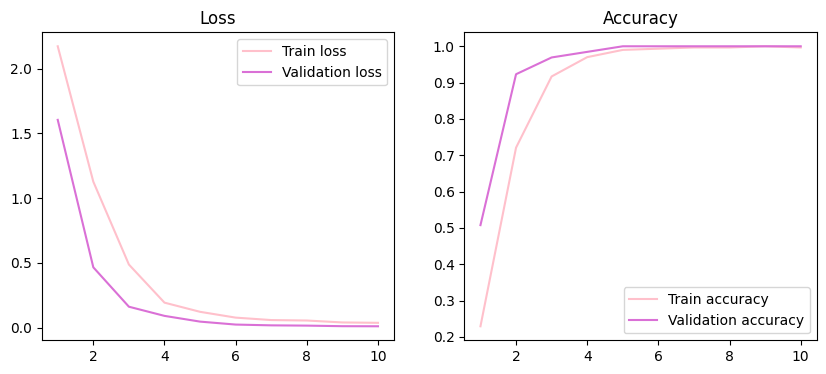

In [19]:
show_training_process(history)

Evaluation

## Fine-tuning with frozen backbone
Validation and test acccuracy is about 0.83. I suspect, it's because model is not as flexible as the one retrained fully.

In [20]:
model_fb = models.resnet18(weights='IMAGENET1K_V1')
for param in model_fb.parameters():
    param.requires_grad = False

num_ftrs = model_fb.fc.in_features

model_fb.fc = nn.Linear(num_ftrs, 10)

model_fb = model_fb.to(device)

criterion_fb = nn.CrossEntropyLoss()

optimizer_fb = optim.SGD(model_fb.fc.parameters(), lr=0.001, momentum=0.9)

In [21]:
history = run_epochs(10, train_loader, val_loader, model_fb, optimizer_fb, criterion_fb)

Epoch 1/10 | train loss: 2.4436, acc: 0.1362 | val loss: 2.2102, acc: 0.1231
Epoch 2/10 | train loss: 2.0452, acc: 0.2957 | val loss: 1.8904, acc: 0.3692
Epoch 3/10 | train loss: 1.6564, acc: 0.4585 | val loss: 1.6232, acc: 0.5231
Epoch 4/10 | train loss: 1.4150, acc: 0.5914 | val loss: 1.3245, acc: 0.5692
Epoch 5/10 | train loss: 1.1929, acc: 0.6844 | val loss: 1.1003, acc: 0.7692
Epoch 6/10 | train loss: 1.0709, acc: 0.7475 | val loss: 1.0326, acc: 0.7846
Epoch 7/10 | train loss: 0.9565, acc: 0.7973 | val loss: 0.9548, acc: 0.8000
Epoch 8/10 | train loss: 0.8919, acc: 0.8007 | val loss: 0.9152, acc: 0.8154
Epoch 9/10 | train loss: 0.8471, acc: 0.8206 | val loss: 0.8682, acc: 0.8000
Epoch 10/10 | train loss: 0.7814, acc: 0.8272 | val loss: 0.8065, acc: 0.8308


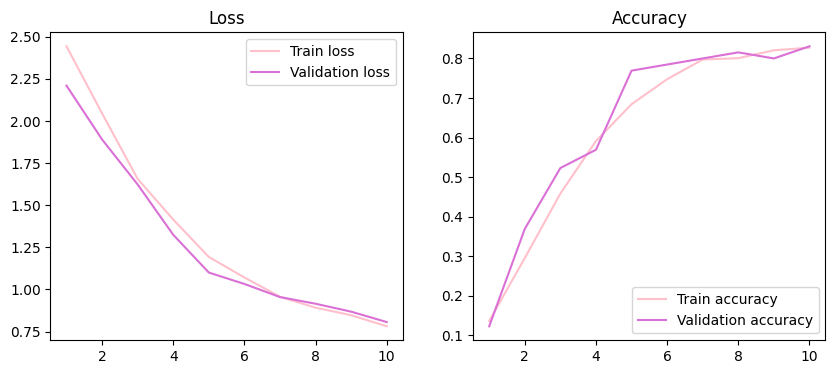

In [22]:
show_training_process(history)

# Evaluation
The dataset is balanced and the task is multiclass classification, so for the metric accuracy is chosen.

In [23]:
def run_test(model, loader):
    model.eval()
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            preds = preds.argmax(1).cpu().numpy()
            all_predictions.append(preds)
            all_targets.append(y_batch.numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    labels = list(range(10))
    cm = confusion_matrix(all_targets, all_predictions)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot(cmap='RdPu')
    plt.title("Confusion Matrix (MNIST)")
    plt.gca().grid(False)
    plt.show()

    acc = (all_predictions == all_targets).mean()
    print(f"Test accuracy: {np.round(acc,4)}")

### Fine-tuned model

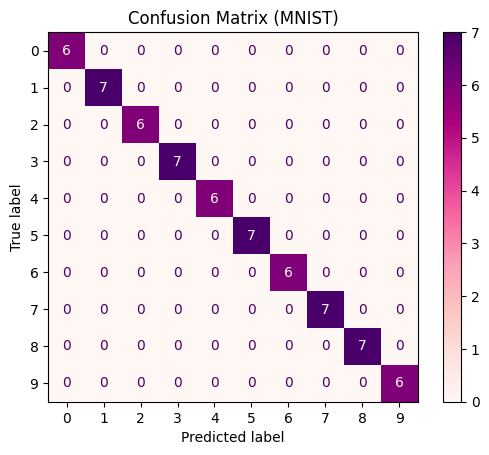

Test accuracy: 1.0


In [24]:
run_test(model, test_loader)

### Model with last layer retrained

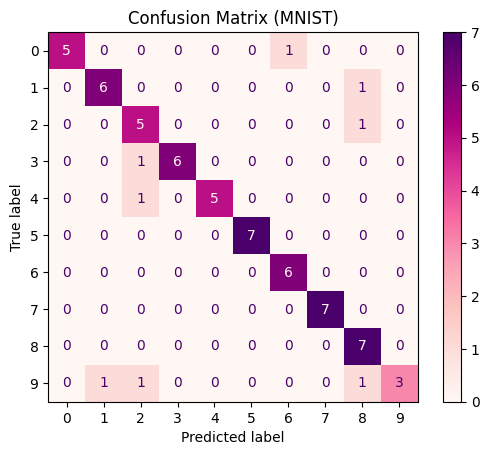

Test accuracy: 0.8769


In [25]:
run_test(model_fb,test_loader)